# Repetition-Neighbor Lag-CRP

> Examine transitions between neighbors of different presentations of repeated items.

The repetition-neighbor CRP analysis examines transitions between items studied near different presentations of the same repeated item. For a repeated item at positions $i$ and $j$, the analysis tracks transitions from $j$'s neighbors to $i$'s neighborhood (j2i), from $i$'s neighbors to $j$'s neighborhood (i2j), or both.

These cross-occurrence neighbor transitions test whether recalling items near one presentation of a repeated item facilitates transitions to items near the other presentation.

## Workflow

In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.repneighborcrp import (
    plot_rep_neighbor_crp,
    subject_rep_neighbor_crp,
    test_rep_neighbor_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .30]
mixed_trial_query = "data['list_type'] > 3"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 3
use_lag2 = True


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


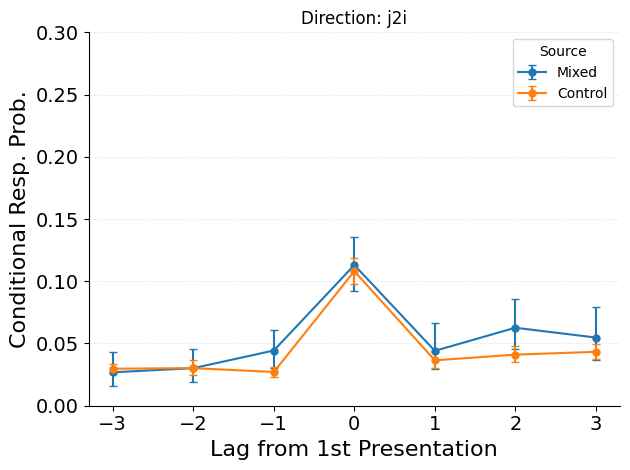

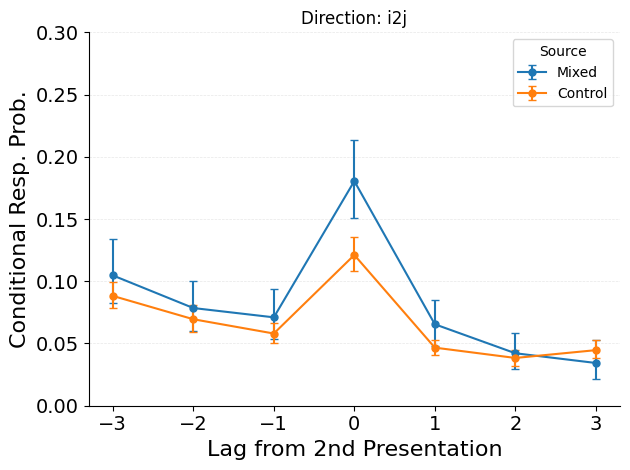

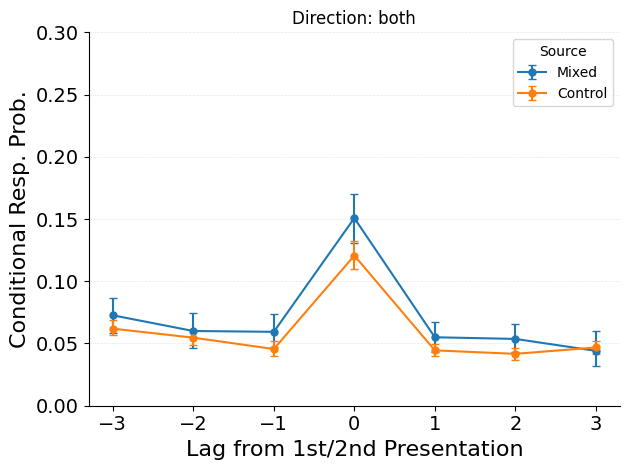

In [4]:
for direction in ["j2i", "i2j", "both"]:
    plot_rep_neighbor_crp(
        datasets=datasets,
        trial_masks=masks,
        max_lag=max_lag,
        min_lag=min_lag,
        direction=direction,
        use_lag2=use_lag2,
        contrast_name="Source",
        labels=["Mixed", "Control"],
    )
    plt.title(f"Direction: {direction}")
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=direction)


In [5]:
for direction in ["j2i", "i2j", "both"]:
    observed_crp = subject_rep_neighbor_crp(
        data, trial_mask, direction, use_lag2, min_lag, max_lag
    )
    control_crp = subject_rep_neighbor_crp(
        control_dataset, control_mask, direction, use_lag2, min_lag, max_lag
    )

    result = test_rep_neighbor_crp_vs_control(observed_crp, control_crp, max_lag, direction)

    print(f"\n{'='*70}")
    print(f"Statistical Test: {direction}")
    print(f"{'='*70}")
    if direction == "j2i":
        print("Tests whether j+1/j+2 → i-neighbors transitions are elevated vs control.")
        print("Significant positive effects support study-phase retrieval at P2.")
    elif direction == "i2j":
        print("Tests whether i+1/i+2 → j-neighbors transitions are elevated vs control.")
        print("(Control condition for asymmetric predictions.)")
    else:
        print("Tests both directions combined.")
    print()
    print(result)


Statistical Test: j2i
Tests whether j+1/j+2 → i-neighbors transitions are elevated vs control.
Significant positive effects support study-phase retrieval at P2.

Direction: j2i
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |   -0.398     0.6929 |    245.0     0.2585 |    -0.0029
   -2 |   -0.005     0.9956 |    285.0     0.6330 |    -0.0000
   -1 |    2.082     0.0450 |    224.0     0.1397 |     0.0173
    0 |    0.392     0.6975 |    308.0     0.9163 |     0.0049
    1 |    0.813     0.4217 |    263.0     0.7545 |     0.0076
    2 |    2.198     0.0348 |    189.0     0.0390 |     0.0216
    3 |    1.016     0.3170 |    300.0     0.8146 |     0.0115

Statistical Test: i2j
Tests whether i+1/i+2 → j-neighbors transitions are elevated vs control.
(Control condition for asymmetric predictions.)

Direction: i2j
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------

## Interpretation

Plots show transition probabilities between neighbors of different presentations. Key patterns:

- **Cross-occurrence facilitation**: elevated transition probabilities between neighbors of different presentations indicate that recalling near one occurrence facilitates recall near the other.
- **Direction asymmetry**: j2i vs. i2j differences reveal whether the direction of cross-occurrence transitions matters.
- **Observed vs. control**: differences isolate repetition-specific neighbor effects beyond shuffled baselines.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits, or `None` for automatic scaling.
- `mixed_trial_query` — query selecting trials with repeated items.
- `control_trial_query` — query selecting trials for the control.
- `control_shuffles` — number of shuffle iterations for building the control dataset.
- `min_lag` — minimum absolute lag included in the analysis.
- `max_lag` — maximum absolute lag displayed.
- `use_lag2` — whether to include lag-2 neighbors in the analysis.